In [1]:
# %matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import datetime, timedelta
import pandas as pd
import h5py

In [2]:
file = "/datasets/FourCastNet/FCN_ERA5_data_v0/train/2015.h5"

In [3]:
with h5py.File(file, 'r') as hdf:
	keys = list(hdf.keys())
	print("Keys:", keys)
	for key in keys:
		data = hdf[key][:1]
		print(f"data for key '{key}' has shape {data.shape}")


Keys: ['fields']
data for key 'fields' has shape (1, 21, 721, 1440)


In [4]:
fields = data

In [5]:
long = np.arange(0, 361, 0.25)
lat = np.arange(90, -90, 0.25)

In [6]:
X,Y = np.meshgrid(long, lat)


In [7]:
fields_rotated = np.rot90(fields, 2, axes=(2, 3))


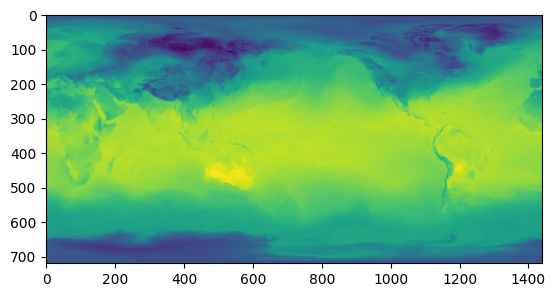

In [8]:
plt.clf()
plt.imshow(fields[0,2,:720, :])

<Figure size 640x480 with 0 Axes>

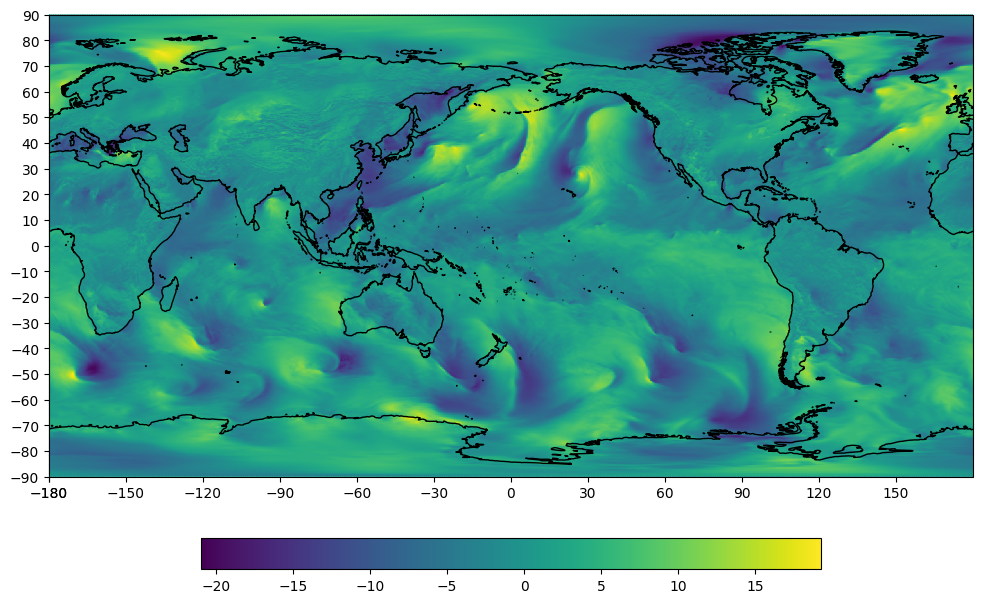

In [13]:
plt.clf()

fig = plt.figure(figsize=(16, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.coastlines(resolution="50m")

ax.set_xticks(range(0, 361, 30), crs=ccrs.PlateCarree())
ax.set_yticks(range(-90, 91, 10), crs=ccrs.PlateCarree())
# ax.gridlines(draw_labels=False)

# 假设 lat 和 lon 是纬度和经度的数组
lat = np.linspace(90, -90, fields.shape[2])
lon = np.linspace(0, 360, fields.shape[3])
lon, lat = np.meshgrid(lon, lat)

c = ax.pcolormesh(lon, lat, fields[0,1], transform=ccrs.PlateCarree(), cmap='viridis')
plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.1, shrink=0.5)
